In [1]:
# pip install nsepy

In [2]:
# pip install yfinance

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
from Univariate import Univariate

In [5]:
obj = Univariate()

In [6]:
import pandas as pd
import numpy as np
import yfinance as yf
import datetime as dt

In [7]:
start = dt.datetime(2013,1,1)
end = dt.datetime(2023,1,1)

stk_data = yf.download("RELIANCE.NS", start=start, end=end)

[*********************100%***********************]  1 of 1 completed


In [8]:
stk_data.head()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2013-01-01,176.018555,177.253853,175.683556,176.709489,6831351
2013-01-02,177.536530,179.221978,176.405928,176.709522,13441898
2013-01-03,180.216461,180.478168,176.835111,177.672587,17266808
2013-01-04,180.446793,181.022562,178.709017,180.457261,13306377
2013-01-07,179.347595,182.362542,178.342613,181.252877,15307180


In [9]:
stk_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2468 entries, 2013-01-01 to 2022-12-30
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   2468 non-null   float64
 1   (High, RELIANCE.NS)    2468 non-null   float64
 2   (Low, RELIANCE.NS)     2468 non-null   float64
 3   (Open, RELIANCE.NS)    2468 non-null   float64
 4   (Volume, RELIANCE.NS)  2468 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 115.7 KB


In [10]:
stk_data.columns = stk_data.columns.get_level_values(0)

In [11]:
stk_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [12]:
dataset=stk_data
quan, qual=obj.quanQual(dataset)

In [13]:
quan

['Close', 'High', 'Low', 'Open', 'Volume']

In [14]:
qual

[]

In [15]:
des_data=obj.Univariate(quan, dataset)

In [16]:
des_data

,Close,High,Low,Open,Volume
Null_count,0,0,0,0,0
NonNull_count,2468,2468,2468,2468,2468
Total_count,2468,2468,2468,2468,2468
Mean,512.994306,519.205173,507.28556,513.364929,18592891.207455
Median,405.177795,409.462583,401.820612,406.613398,14815221.0
Mode,209.815094,162.880536,230.518032,160.587923,0
Q1:25%,209.884808,212.311171,208.492233,210.400096,11076884.75
Q2:50%,405.177795,409.462583,401.820612,406.613398,14815221.0
Q3:75%,835.923187,849.231391,819.730085,833.860112,20989320.25
99%,1226.854645,1242.160979,1211.581222,1228.849291,73185442.65


In [17]:
des_data["Low"]

Null_count                   0
NonNull_count             2468
Total_count               2468
Mean                 507.28556
Median              401.820612
Mode                230.518032
Q1:25%              208.492233
Q2:50%              401.820612
Q3:75%              819.730085
99%                1211.581222
Q4:100%            1267.708955
IQR                 611.237852
1.5rule             916.856778
Lesser             -708.364545
Greater            1736.586863
Min                 159.991203
Max                1267.708955
kurtosis              -0.89655
skew                  0.743827
var              118565.195343
std                 344.332972
Name: Low, dtype: object

In [18]:
des_data["High"]

Null_count                   0
NonNull_count             2468
Total_count               2468
Mean                519.205173
Median              409.462583
Mode                162.880536
Q1:25%              212.311171
Q2:50%              409.462583
Q3:75%              849.231391
99%                1242.160979
Q4:100%            1299.582709
IQR                  636.92022
1.5rule             955.380331
Lesser              -743.06916
Greater            1804.611722
Min                 162.880536
Max                1299.582709
kurtosis              -0.90714
skew                   0.73865
var              124129.574985
std                 352.320273
Name: High, dtype: object

In [19]:
np.percentile(dataset["Low"],99)

1211.5812217009181

In [20]:
np.percentile(dataset["High"],80)

937.4691385431753

In [21]:
def get_pdf_probability(dataset, startrange, endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    
    ax = sns.distplot(dataset, kde=True, kde_kws={'color':'blue'}, color='Green')
    pyplot.axvline(startrange, color='Red')
    pyplot.axvline(endrange, color='Red')
    
    # generate a sample
    sample = dataset
    
    # calculate parameters
    sample_mean = sample.mean()
    sample_std = sample.std()
    print("Mean=%.3f, Standard Deviation=%.3f" % (sample_mean, sample_std))
    
    # define the distribution
    dist = norm(sample_mean, sample_std)
    
    # sample probabilities for a range of outcomes
    values = [value for value in range(startrange, endrange)]
    probabilities = [dist.pdf(value) for value in values]
    prob = sum(probabilities)
    
    print("The area between range({},{}):{}".format(startrange, endrange, sum(probabilities)))
    
    return prob

Mean=507.286, Standard Deviation=344.333
The area between range(219,400):0.17630592859461247


0.17630592859461247

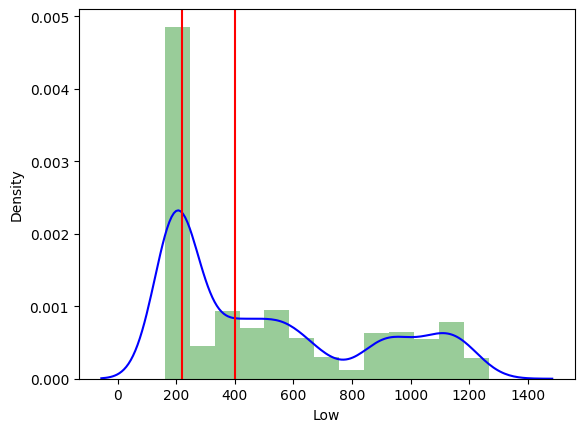

In [22]:
get_pdf_probability(dataset["Low"], 219, 400)

In [23]:
def stdNBgraph(dataset):
    # Converted to standard Normal Distribution
    import seaborn as sns
    
    mean = dataset.mean()
    std = dataset.std()
    
    values = [i for i in dataset]
    
    z_score = [((j - mean) / std) for j in values]
    
    sns.distplot(z_score, kde=True)
    
    sum(z_score) / len(z_score)
    # z_score.std()

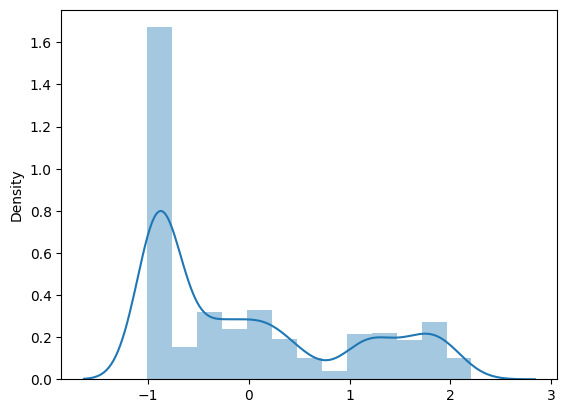

In [24]:
stdNBgraph(dataset["Low"])

In [25]:
def freqTable(columnName, dataset):
    import pandas as pd
    
    frq = pd.DataFrame()
    frq["Unique_Values"] = dataset[columnName].value_counts().index
    frq["Frequency"] = dataset[columnName].value_counts().values
    frq["Relative_Fre"] = dataset[columnName].value_counts().values / len(dataset[columnName]) * 100
    frq["Cumulative"] = frq["Relative_Fre"].cumsum()
    
    return frq

In [26]:
freqTable("Low", dataset)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,230.518032,2,0.081037,0.081037
1,175.683556,1,0.040519,0.121556
2,539.910437,1,0.040519,0.162075
3,536.823731,1,0.040519,0.202593
4,530.583177,1,0.040519,0.243112
...,...,...,...,...
2462,214.302883,1,0.040519,99.837925
2463,212.549877,1,0.040519,99.878444
2464,213.656478,1,0.040519,99.918963
2465,213.645535,1,0.040519,99.959481


In [27]:
freqTable("High", dataset)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,177.253853,1,0.040519,0.040519
1,549.573227,1,0.040519,0.081037
2,556.059964,1,0.040519,0.121556
3,539.172351,1,0.040519,0.162075
4,542.728797,1,0.040519,0.202593
...,...,...,...,...
2463,215.771013,1,0.040519,99.837925
2464,214.905461,1,0.040519,99.878444
2465,217.852693,1,0.040519,99.918963
2466,217.052898,1,0.040519,99.959481


In [28]:
fh=freqTable("High", dataset)

In [29]:
fh.sort_values(by="Frequency", ascending=False)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,177.253853,1,0.040519,0.040519
1648,179.839636,1,0.040519,66.815235
1641,192.066908,1,0.040519,66.531605
1642,194.370010,1,0.040519,66.572123
1643,180.478168,1,0.040519,66.612642
...,...,...,...,...
823,1189.013857,1,0.040519,33.387358
824,1182.554553,1,0.040519,33.427877
825,1160.414342,1,0.040519,33.468395
826,1163.518550,1,0.040519,33.508914


In [30]:
fhs=fh[fh["Frequency"]==1]["Unique_Values"].sort_values(ascending=False)

In [31]:
fhs

661     1299.582709
660     1297.239311
659     1286.774072
878     1281.928143
879     1280.403842
           ...     
1672     164.377536
1671     164.136753
1668     163.812228
1673     163.393490
1667     162.880536
Name: Unique_Values, Length: 2468, dtype: float64

In [32]:
stk_data

Price,Close,High,Low,Open,Volume
Date,,,,,
2013-01-01,176.018555,177.253853,175.683556,176.709489,6831351
2013-01-02,177.536530,179.221978,176.405928,176.709522,13441898
2013-01-03,180.216461,180.478168,176.835111,177.672587,17266808
2013-01-04,180.446793,181.022562,178.709017,180.457261,13306377
2013-01-07,179.347595,182.362542,178.342613,181.252877,15307180
...,...,...,...,...,...
2022-12-26,1152.220215,1160.414342,1137.772122,1147.974874,5990242
2022-12-27,1161.646973,1163.518550,1148.203131,1154.936462,5763271
2022-12-28,1161.532837,1163.975064,1151.056230,1158.588423,7459393


In [33]:
stk_data.to_csv("stk_data.csv")